**Purpose:** Download daily prices for the 11 SPDR sector ETFs via yfinance.

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


# Extract ETFs related data

The ETFs listed below are sector-specific funds that track the performance of various sectors in the S&P 500 index. Each ETF is identified by its ticker symbol and ISIN code, along with links to more information from SSGA and Cbonds.

https://www.sectorspdrs.com

| Sector                 | Ticker | ISIN                                         | Inception Date |
| ---------------------- | -----: | -------------------------------------------- | ---------------|
| Materials              |    XLB | **US81369Y1001**. ([SSGA][1], [Cbonds][2])   | 16/12/1998 |
| Energy                 |    XLE | **US81369Y5069**. ([SSGA][3], [Cbonds][4])   | 16/12/1998 |
| Financials             |    XLF | **US81369Y6059**. ([SSGA][5], [Cbonds][6])   | 16/12/1998 |
| Industrials            |    XLI | **US81369Y7040**. ([SSGA][7], [Cbonds][8])   | 16/12/1998 |
| Technology             |    XLK | **US81369Y8030**. ([SSGA][9], [Cbonds][10])  | 16/12/1998 |
| Health Care            |    XLV | **US81369Y2090**. ([SSGA][11], [Cbonds][12]) | 16/12/1998 |
| Consumer Discretionary |    XLY | **US81369Y4070**. ([SSGA][13], [Cbonds][14]) | 16/12/1998 |
| Consumer Staples       |    XLP | **US81369Y3080**. ([SSGA][15], [Cbonds][16]) | 16/12/1998 |
| Utilities              |    XLU | **US81369Y8865**. ([SSGA][19], [Cbonds][20]) | 16/12/1998 |
| Real Estate            |   XLRE | **US81369Y8600**. ([SSGA][21], [Cbonds][22]) | 07/10/2015 |
| Communication Services |    XLC | **US81369Y8527**. ([SSGA][17], [Cbonds][18]) | 18/06/2018 |

[1]: https://www.ssga.com/nl/en_gb/intermediary/etfs/the-materials-select-sector-spdr-fund-xlb?utm_source=chatgpt.com "XLB: The Materials Select Sector SPDR® Fund"
[2]: https://cbonds.com/etf/273/?utm_source=chatgpt.com "XLB - Materials Select Sector SPDR Fund (USD), US81369Y1001"
[3]: https://www.ssga.com/us/en/intermediary/etfs/the-energy-select-sector-spdr-fund-xle?utm_source=chatgpt.com "XLE: The Energy Select Sector SPDR® Fund"
[4]: https://cbonds.com/etf/87/?utm_source=chatgpt.com "XLE - Energy Select Sector SPDR Fund (USD), US81369Y5069"
[5]: https://www.ssga.com/us/en/intermediary/etfs/the-financial-select-sector-spdr-fund-xlf?utm_source=chatgpt.com "XLF: The Financial Select Sector SPDR® Fund"
[6]: https://cbonds.com/etf/1/?utm_source=chatgpt.com "XLF - Financial Select Sector SPDR Fund (USD), US81369Y6059"
[7]: https://www.ssga.com/se/en_gb/intermediary/etfs/the-industrial-select-sector-spdr-fund-xli?utm_source=chatgpt.com "XLI: The Industrial Select Sector SPDR® Fund"
[8]: https://cbonds.com/etf/91/?utm_source=chatgpt.com "XLI - Industrial Select Sector SPDR Fund (USD), US81369Y7040"
[9]: https://www.ssga.com/us/en/intermediary/etfs/the-technology-select-sector-spdr-fund-xlk?utm_source=chatgpt.com "XLK: The Technology Select Sector SPDR® Fund"
[10]: https://cbonds.com/etf/21/?utm_source=chatgpt.com "XLK - Technology Select Sector SPDR Fund (USD), US81369Y8030"
[11]: https://www.ssga.com/us/en/intermediary/etfs/the-health-care-select-sector-spdr-fund-xlv?utm_source=chatgpt.com "XLV: The Health Care Select Sector SPDR® Fund"
[12]: https://cbonds.com/etf/89/?utm_source=chatgpt.com "XLV - Health Care Select Sector SPDR Fund (USD), US81369Y2090"
[13]: https://www.ssga.com/us/en/intermediary/etfs/the-consumer-discretionary-select-sector-spdr-fund-xly?utm_source=chatgpt.com "XLY: The Consumer Discretionary Select Sector SPDR® Fund"
[14]: https://cbonds.com/etf/79/?utm_source=chatgpt.com "XLY - Consumer Discretionary Select Sector SPDR Fund ... - Cbonds"
[15]: https://www.ssga.com/us/en/intermediary/etfs/the-consumer-staples-select-sector-spdr-fund-xlp?utm_source=chatgpt.com "XLP: The Consumer Staples Select Sector SPDR® Fund"
[16]: https://cbonds.com/etf/81/?utm_source=chatgpt.com "Consumer Staples Select Sector SPDR Fund (USD), US81369Y3080"
[17]: https://www.ssga.com/us/en/intermediary/etfs/the-communication-services-select-sector-spdr-fund-xlc?utm_source=chatgpt.com "XLC: The Communication Services Select Sector SPDR® Fund"
[18]: https://cbonds.com/etf/2271/?utm_source=chatgpt.com "XLC - The Communication Services Select Sector SPDR® Fund ..."
[19]: https://www.ssga.com/us/en/intermediary/etfs/the-utilities-select-sector-spdr-fund-xlu?utm_source=chatgpt.com "XLU: The Utilities Select Sector SPDR® Fund"
[20]: https://cbonds.com/etf/111/?utm_source=chatgpt.com "XLU - Utilities Select Sector SPDR Fund (USD), US81369Y8865"
[21]: https://www.ssga.com/us/en/intermediary/etfs/the-real-estate-select-sector-spdr-fund-xlre?utm_source=chatgpt.com "XLRE: The Real Estate Select Sector SPDR® Fund"
[22]: https://cbonds.com/etf/2273/?utm_source=chatgpt.com "The Real Estate Select Sector SPDR® Fund (USD), US81369Y8600"

Some articles use [Alpha Vantage](https://www.alphavantage.co) as a data source for financial information [**2b4c0**, **34309**] or [FinHub](https://finnhub.io) [**a2e88**]. But since we are dealing with distributing ETFs, [yfinance](https://pypi.org/project/yfinance/) (like [**0973b**, **a12be**]) will be used to extract the data, due to its ease of use, robustness to handle dividends and possible splits, and cheapness (free to use, as Alpha Vantage and FinHub have limitations on free usage).

This will allow us to either use the adjusted close prices [**a12be**] or calculate the total return based on dividends and splits, a decision that will be made later on.

In [32]:
import yfinance as yf
import pandas as pd

etfs = {
    "XLB": {
        "name": "Materials Select Sector SPDR Fund",
        "isin": "US81369Y1001",
        "inception_date": "16/12/1998"
    },
    "XLE": {
        "name": "Energy Select Sector SPDR Fund",
        "isin": "US81369Y5069",
        "inception_date": "16/12/1998"
    },
    "XLF": {
        "name": "Financial Select Sector SPDR Fund",
        "isin": "US81369Y6059",
        "inception_date": "16/12/1998"
    },
    "XLI": {
        "name": "Industrial Select Sector SPDR Fund",
        "isin": "US81369Y7040",
        "inception_date": "16/12/1998"
    },
    "XLK": {
        "name": "Technology Select Sector SPDR Fund",
        "isin": "US81369Y8030",
        "inception_date": "16/12/1998"
    },
    "XLV": {
        "name": "Health Care Select Sector SPDR Fund",
        "isin": "US81369Y2090",
        "inception_date": "16/12/1998"
    },
    "XLY": {
        "name": "Consumer Discretionary Select Sector SPDR Fund",
        "isin": "US81369Y4070",
        "inception_date": "16/12/1998"
    },
    "XLP": {
        "name": "Consumer Staples Select Sector SPDR Fund",
        "isin": "US81369Y3080",
        "inception_date": "16/12/1998"
    },
    "XLU": {
        "name": "Utilities Select Sector SPDR Fund",
        "isin": "US81369Y8865",
        "inception_date": "16/12/1998"
    },
    "XLRE": {
        "name": "Real Estate Select Sector SPDR Fund",
        "isin": "US81369Y8600",
        "inception_date": "07/10/2015"
    },
    "XLC": {
        "name": "Communication Services Select Sector SPDR Fund",
        "isin": "US81369Y8527",
        "inception_date": "18/06/2018"
    }
}

for ticker, details in etfs.items():
    data = yf.Ticker(ticker)
    df = data.history(period="max", auto_adjust=False)
    details["data"] = df

etfs["XLRE"]["data"].tail(3)

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2025-11-24 00:00:00-05:00,40.939999,41.035000,40.630001,40.959999,40.959999,6796900,0.0,0.0,0.0
2025-11-25 00:00:00-05:00,41.070000,41.459999,41.040001,41.290001,41.290001,5898100,0.0,0.0,0.0
2025-11-26 00:00:00-05:00,41.169998,41.685001,41.160000,41.470001,41.470001,6813200,0.0,0.0,0.0


The object `etfs` is a dictionary that contains the ticker symbol, ISIN code, and inception date for each ETF. The data will be extracted using the `yfinance` library, which provides an easy way to access historical market data.

The `data` key inside each ETF within the `etfs` dictionary will hold the historical data for each ETF, including: Open, High, Low, Close, Adj Close, Volume, Dividends, Stock Splits, Capital Gains.

The whole `etfs` dictionary will be saved into a pickle file for later use, allowing us to load the data without having to re-fetch it from the internet.

In [33]:
import pickle

data_already_saved = True  # Change this to False if you want to save new data

if not data_already_saved:
    with open("etfs_data.pkl", "wb") as f:
        pickle.dump(etfs, f)
    print("ETFs data saved to etfs_data.pkl")

else:
    with open("etfs_data.pkl", "rb") as f:
        etfs = pickle.load(f)
    print("ETFs data loaded from etfs_data.pkl")

ETFs data loaded from etfs_data.pkl


# ETFs Exploratory Data Analysis

Due to some different inception dates, some ETFs may not have data for the same period. This will be handled later on either by just starting the analysis from the latest inception date or by just allowing the portfolio to alocate funds to each ETF after its inception date.

In [34]:
for etf, details in etfs.items():
    inception_date = details["inception_date"]
    first_price = details["data"].head(1).index.strftime('%d/%m/%Y').values[0]
    last_price = details["data"].tail(1).index.strftime('%d/%m/%Y').values[0]
    current_price = details["data"].tail(1)["Close"].values[0]

    print(f"{etf}: {inception_date} | {first_price} -- {last_price} ({current_price:.2f})")

XLB: 16/12/1998 | 22/12/1998 -- 15/08/2025 (90.03)
XLE: 16/12/1998 | 22/12/1998 -- 15/08/2025 (85.56)
XLF: 16/12/1998 | 22/12/1998 -- 15/08/2025 (52.46)
XLI: 16/12/1998 | 22/12/1998 -- 15/08/2025 (150.44)
XLK: 16/12/1998 | 22/12/1998 -- 15/08/2025 (265.70)
XLV: 16/12/1998 | 22/12/1998 -- 15/08/2025 (136.21)
XLY: 16/12/1998 | 22/12/1998 -- 15/08/2025 (229.04)
XLP: 16/12/1998 | 22/12/1998 -- 15/08/2025 (82.02)
XLU: 16/12/1998 | 22/12/1998 -- 15/08/2025 (85.62)
XLRE: 07/10/2015 | 08/10/2015 -- 15/08/2025 (41.33)
XLC: 18/06/2018 | 19/06/2018 -- 15/08/2025 (111.48)


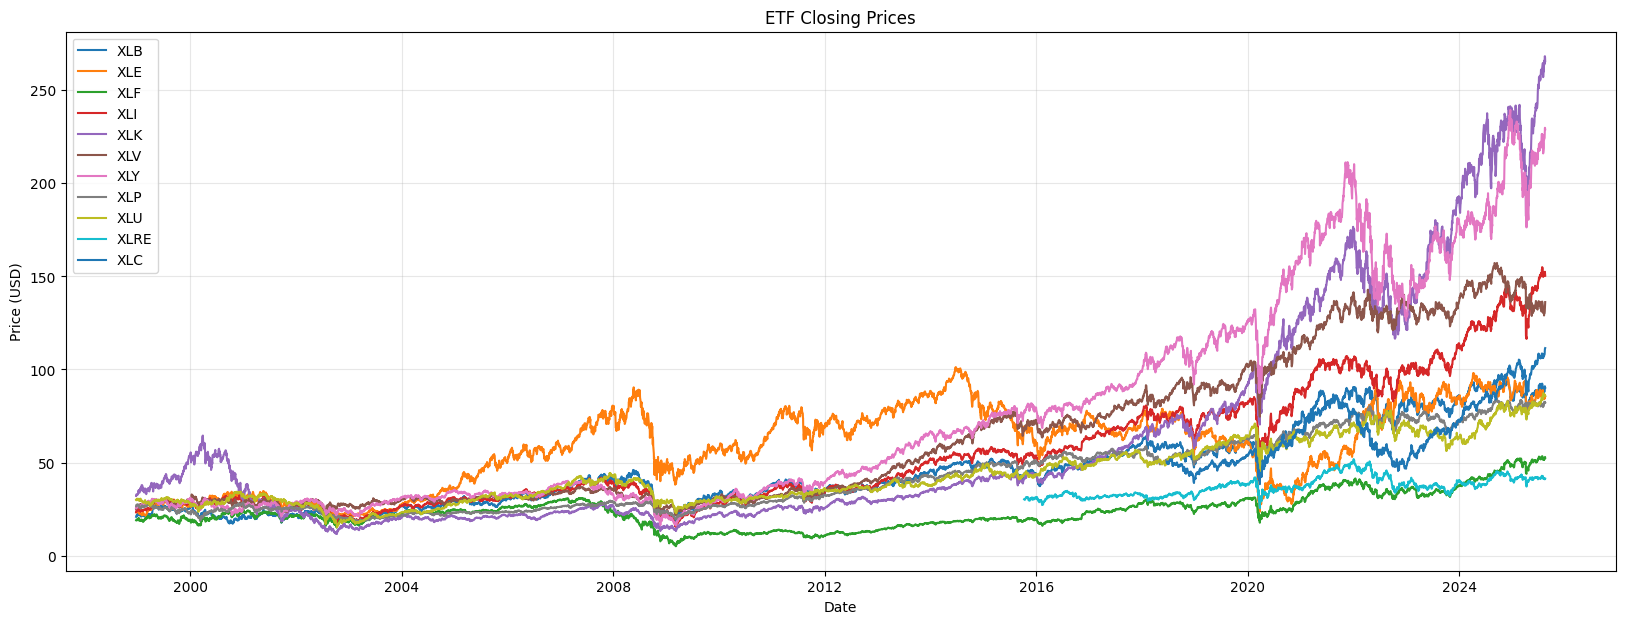

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 7))
for etf, details in etfs.items():
    plt.plot(details["data"].index, details["data"]["Close"], label=etf)
plt.title("ETF Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

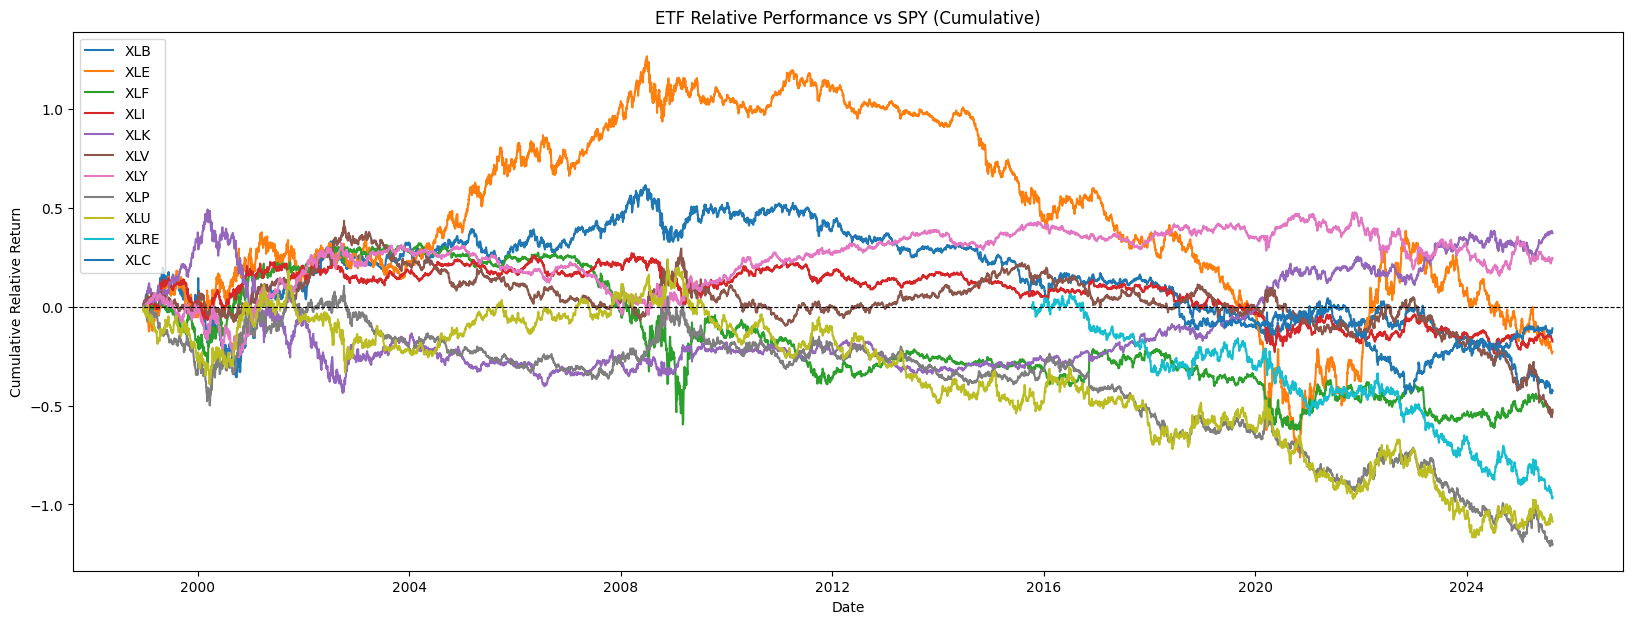

In [36]:
# Download SPY (S&P 500 proxy)
spy = yf.Ticker("SPY")
spy_df = spy.history(period="max", auto_adjust=True)
spy_returns = spy_df["Close"].pct_change()

plt.figure(figsize=(20, 7))

# For each ETF
for etf, details in etfs.items():
    df = details["data"]
    df = df.copy()  # avoid SettingWithCopyWarning
    df["Close"] = df["Close"].astype(float)
    df = df[df.index.isin(spy_returns.index)]  # align dates with SPY

    # Calculate ETF daily returns
    etf_returns = df["Close"].pct_change()

    # Align with SPY
    aligned = pd.concat([etf_returns, spy_returns], axis=1, join="inner")
    aligned.columns = ["ETF", "SPY"]
    
    # Relative performance: ETF return - SPY return
    aligned["RelativePerf"] = aligned["ETF"] - aligned["SPY"]

    # Save it back if needed
    details["relative_perf"] = aligned["RelativePerf"]

    # Plot
    plt.plot(aligned.index, aligned["RelativePerf"].cumsum(), label=etf)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend()
plt.title("ETF Relative Performance vs SPY (Cumulative)")
plt.xlabel("Date")
plt.ylabel("Cumulative Relative Return")
plt.show()


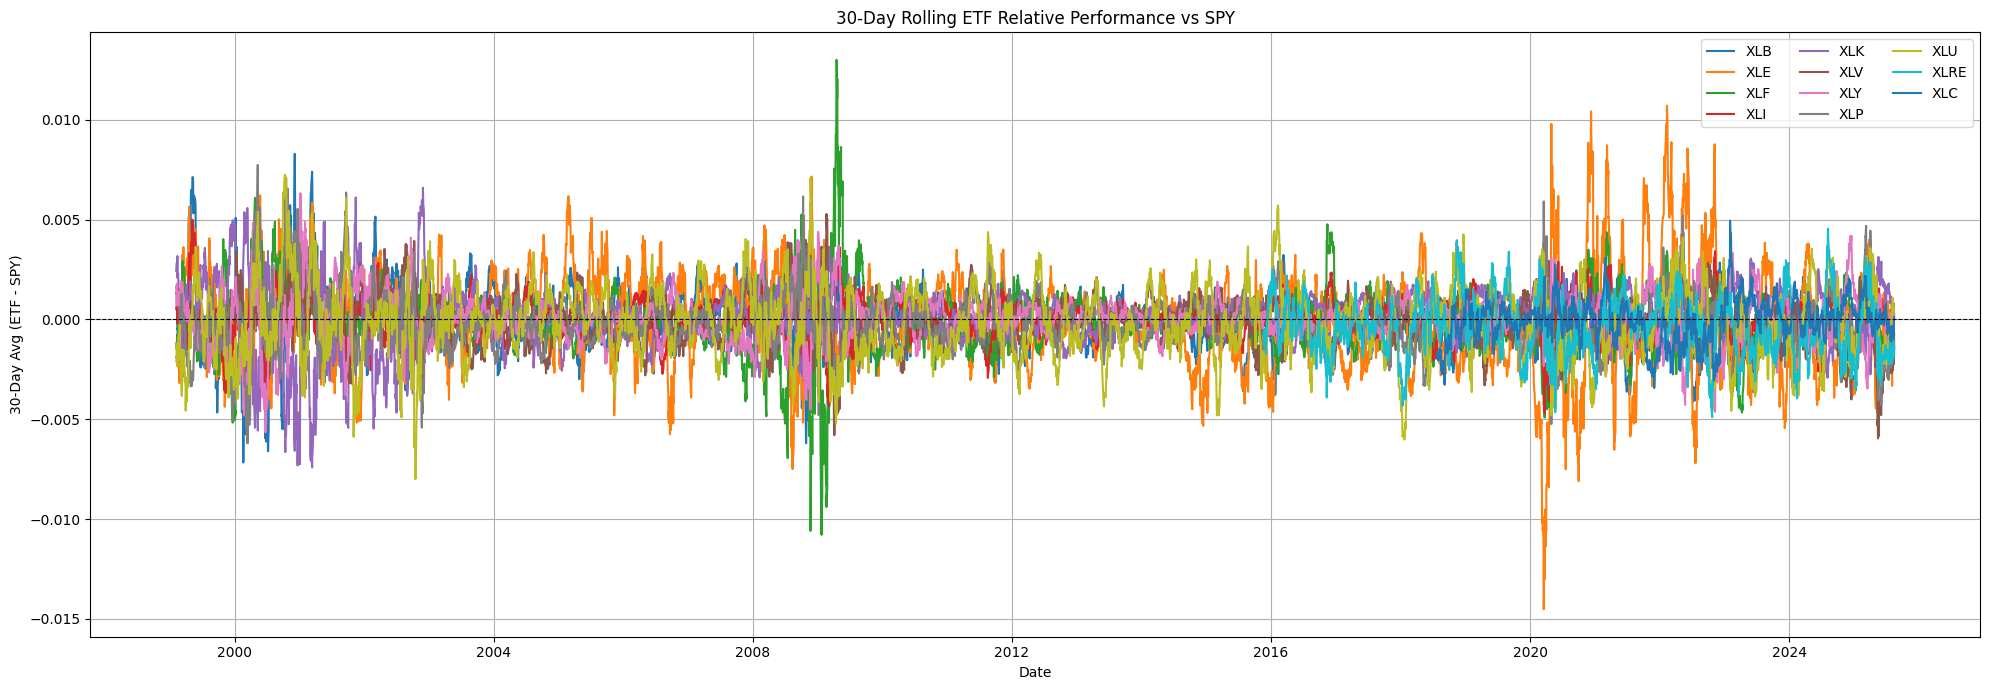

In [37]:
# Download SPY (S&P 500 proxy)
spy = yf.Ticker("SPY")
spy_df = spy.history(period="max", auto_adjust=True)
spy_returns = spy_df["Close"].pct_change()

plt.figure(figsize=(20, 7))

# For each ETF
rolling_window = 30  # you can change this to 10, 50, etc.

for etf, details in etfs.items():
    df = details["data"].copy()
    df["Close"] = df["Close"].astype(float)
    df = df[df.index.isin(spy_returns.index)]

    etf_returns = df["Close"].pct_change()
    aligned = pd.concat([etf_returns, spy_returns], axis=1, join="inner")
    aligned.columns = ["ETF", "SPY"]
    aligned["RelativePerf"] = aligned["ETF"] - aligned["SPY"]

    # Rolling mean to smooth daily relative performance
    aligned["RollingRelativePerf"] = aligned["RelativePerf"].rolling(rolling_window).mean()

    # Save if needed
    details["rolling_relative_perf"] = aligned["RollingRelativePerf"]

    # Plot rolling relative performance
    plt.plot(aligned.index, aligned["RollingRelativePerf"], label=etf)

# Formatting
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title(f"{rolling_window}-Day Rolling ETF Relative Performance vs SPY")
plt.xlabel("Date")
plt.ylabel(f"{rolling_window}-Day Avg (ETF - SPY)")
plt.legend(ncol=3)
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
# Check for missing values
for etf, details in etfs.items():
    missing_data = details["data"].isnull().sum()
    if missing_data.any():
        print(f"{etf} has missing data:")
        print(missing_data[missing_data > 0])


for etf, details in etfs.items():
    df = details["data"]
    df = df.sort_index()
    all_days = pd.date_range(start=df.index.min(), end=df.index.max())
    missing_dates = all_days.difference(df.index)
    
    if not missing_dates.empty:
        print(f"{etf} has missing days: {len(missing_dates)}")

XLB has missing days: 3031
XLE has missing days: 3031
XLF has missing days: 3031
XLI has missing days: 3031
XLK has missing days: 3031
XLV has missing days: 3031
XLY has missing days: 3031
XLP has missing days: 3031
XLU has missing days: 3031
XLRE has missing days: 1122
XLC has missing days: 815


The missing dates in the dataset likely correspond to weekends and market holidays. Financial markets, such as the NYSE, are closed on Saturdays, Sundays, and designated holidays. Therefore, the gaps in the time series data are expected and do not indicate missing or erroneous records.

To deal with the missing dates, a solution would be to interpolate the missing values, which is a common practice in time series analysis [**d892a**, **0973b**].

# Correlation and Cointegration of ETFs

**Correlation** quantifies the degree to which two variables move together linearly over time. Its values range from -1 to +1, where +1 indicates perfect positive correlation, -1 indicates perfect negative correlation, and 0 indicates no linear relationship. Correlation primarily captures short-term co-movement, providing insight into how daily or periodic changes in one asset correspond to changes in another. However, correlation does not indicate whether two time series maintain a stable relationship over the long term.

**Cointegration**, in contrast, assesses whether two or more non-stationary time series exhibit a stable long-term equilibrium relationship. Even if the individual series trend independently, a linear combination of them may be stationary, implying that deviations from equilibrium are temporary and the series tend to move together over time. Cointegration is typically tested using the Engle-Granger procedure or similar statistical methods.

| Concept        | Definition                            | Timeframe   | Interpretation                                  |
|----------------|--------------------------------------|------------|------------------------------------------------|
| Correlation     | Linear co-movement between variables | Short-term | Indicates how series move together on a daily or periodic basis |
| Cointegration   | Long-term equilibrium relationship   | Long-term  | Indicates that series tend to revert to a stable relationship over time |

Even if two ETFs show high correlation, meaning their prices tend to move up and down together in the short term, this does not necessarily mean they are cointegrated. In finance, cointegration refers to a special kind of relationship between time series: it means that, despite individual price movements, the series share a stable long-term equilibrium. Put simply, the difference or spread between the two series tends to stay around a constant level over time, and any deviation from this level is likely to eventually revert back. 

Being cointegrated has important implications. For example, if two ETFs are cointegrated, a trader could exploit temporary deviations from their equilibrium to design a pairs trading strategy, buying one ETF and selling the other when their spread is unusually wide, expecting it to revert. In risk management, cointegration indicates that assets are linked in the long run, so portfolio diversification benefits may be lower than expected if you only looked at correlation.

**Conclusion:**  
- **Correlation** identifies short-term co-movement.  
- **Cointegration** identifies a long-term stable relationship and equilibrium.  
- **Implication:** Cointegrated assets may move together over time, and deviations are often temporary, offering potential trading or risk management opportunities.

Next, we will calculate the correlation and cointegration of the ETFs using the `statsmodels` library. The correlation matrix and the cointegration matrix will be plotted using heatmaps for better visualization. The correlation matrix will show how closely the ETFs move together, while the cointegration matrix will indicate which ETFs maintain a stable long-term relationship.

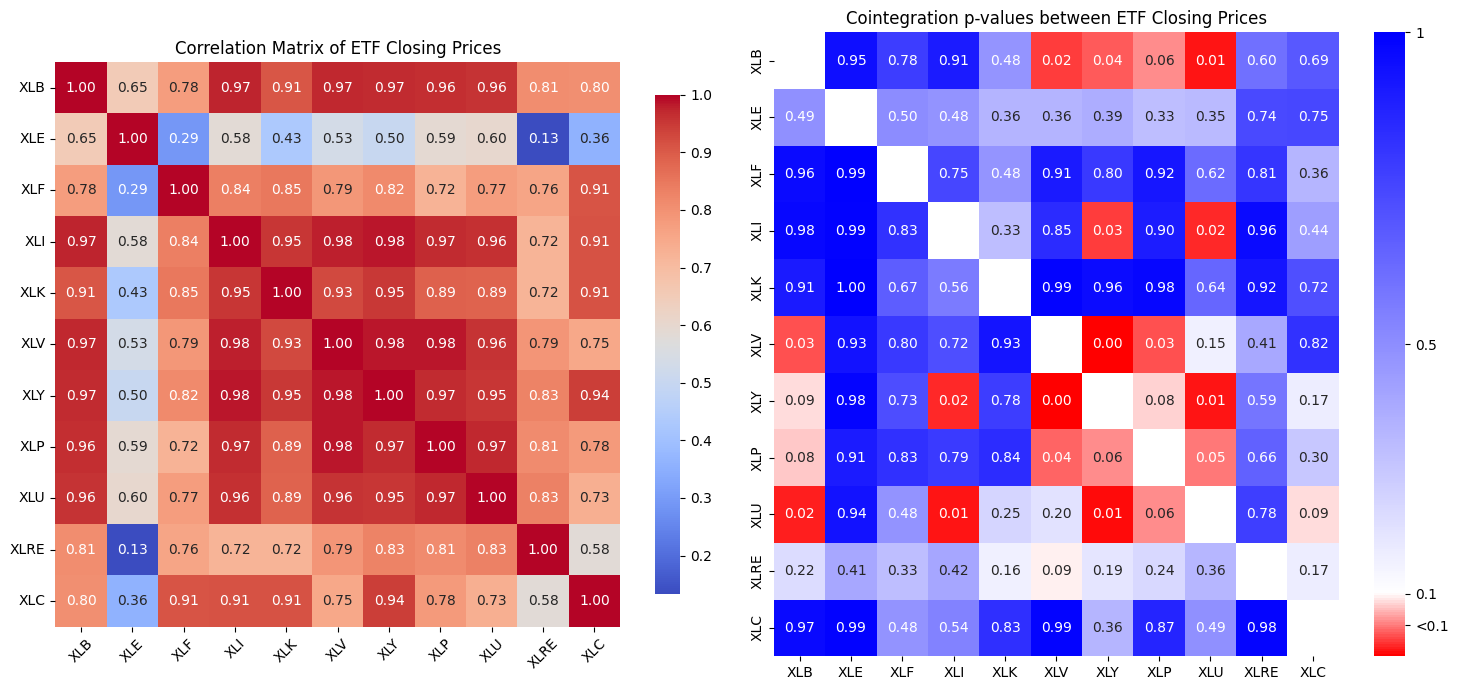

In [39]:
import seaborn as sns
from statsmodels.tsa.stattools import coint
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- Correlation heatmap ---
correlation_matrix = pd.DataFrame({etf: details["data"]["Close"] for etf, details in etfs.items()}).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Correlation Matrix of ETF Closing Prices")
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- Cointegration heatmap ---
etf_names = list(etfs.keys())
n = len(etf_names)
coint_matrix = pd.DataFrame(index=etf_names, columns=etf_names)

for i in range(n):
    for j in range(n):
        if i != j:
            merged = etfs[etf_names[i]]['data'][['Close']].join(
                     etfs[etf_names[j]]['data'][['Close']], how='inner',
                     lsuffix='_i', rsuffix='_j')
            score, pvalue, _ = coint(merged[f'Close_i'], merged[f'Close_j'])
            coint_matrix.iloc[i, j] = pvalue
        else:
            coint_matrix.iloc[i, j] = None

coint_matrix = coint_matrix.astype(float)

# Create a custom colormap: red for 0-0.1, white→blue for 0.1-1
cdict = {
    'red':   [(0.0, 1.0, 1.0),   # red for <0.1
              (0.1, 1.0, 1.0),
              (1.0, 0.0, 0.0)],  # blue gradient starts here (red=0)
    'green': [(0.0, 0.0, 0.0),
              (0.1, 1.0, 1.0),
              (1.0, 0.0, 0.0)],
    'blue':  [(0.0, 0.0, 0.0),
              (0.1, 1.0, 1.0),
              (1.0, 1.0, 1.0)]
}
custom_cmap = LinearSegmentedColormap('RedWhiteBlue', segmentdata=cdict)

# Plot heatmap
sns.heatmap(coint_matrix, annot=True, fmt=".2f", cmap=custom_cmap, vmin=0, vmax=1,
            ax=axes[1])
axes[1].set_title("Cointegration p-values between ETF Closing Prices")

# Customize colorbar ticks
cbar = axes[1].collections[0].colorbar
cbar.set_ticks([0.05, 0.1, 0.5, 1])
cbar.set_ticklabels(['<0.1', '0.1', '0.5', '1'])

# --- Plot the heatmaps ---
plt.tight_layout()
plt.show()

Most ETFs tend to show high correlation because, as expected, they generally move upward together with the market. This short-term co-movement is normal and reflects broad market trends. However, when we examine cointegration, most ETFs do not exhibit a stable long-term relationship, as indicated by high p-values in cointegration tests. 

This lack of cointegration is actually a positive sign for portfolio construction from a risk management perspective. Since the assets are not tied together in the long run, the portfolio is less likely to experience synchronized drawdowns, providing better diversification benefits. 

That said, a few ETFs do show evidence of cointegration. It will be interesting to monitor how the portfolio handles these cases and whether the long-term relationships impact overall risk and returns.


In [ ]:
# for key, details in etfs.items():
#     df = etfs[key]['data']
#     filtered_df = df.loc["2015-07-01" : "2025-06-30"]
#     etfs[key]['data'] = filtered_df

#     print(f"{key}: {filtered_df.index.min().date()} -- {filtered_df.index.max().date()}")

# with open(str(PROJECT_ROOT / "01_data/processed/etfs_0.pkl"), "wb") as f:
#     pickle.dump(etfs, f)

XLB: 2015-07-01 -- 2025-06-30
XLE: 2015-07-01 -- 2025-06-30
XLF: 2015-07-01 -- 2025-06-30
XLI: 2015-07-01 -- 2025-06-30
XLK: 2015-07-01 -- 2025-06-30
XLV: 2015-07-01 -- 2025-06-30
XLY: 2015-07-01 -- 2025-06-30
XLP: 2015-07-01 -- 2025-06-30
XLU: 2015-07-01 -- 2025-06-30
XLRE: 2015-10-08 -- 2025-06-30
XLC: 2018-06-19 -- 2025-06-30
